# 🐾 Animal Disease Detection — Data Preparation Pipeline
### From Raw Clinical Data to ML-Ready Dataset
**Objective:** Animal Disease Detection & Classification

---

### What this notebook does

Starting from the `cleaned_animal_disease_prediction.csv` file, this notebook produces  
a single clean, feature-engineered dataset ready to train a disease classification model.

| Step | Description |
|------|-------------|
| 1 | Load raw animal clinical data |
| 2 | Initial exploration & quality check |
| 3 | Parse & clean mixed-format columns |
| 4 | Encode binary symptom flags |
| 5 | Feature engineering (risk score, symptom count, etc.) |
| 6 | Encode categorical variables |
| 7 | Encode the target label (`Disease_Prediction`) |
| 8 | Normalize numerical features |
| 9 | Final quality check & save |

**Input file:** `cleaned_animal_disease_prediction.csv`  
**Output:** `animal_disease_ml_ready.csv` + `disease_label_map.json`

---

> **Data source note:** This dataset contains clinical records of animals including  
> species, breed, age, weight, symptoms, vital signs, and diagnosed diseases.  
> It serves as the foundation for a supervised classification model.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Data

In [2]:
df = pd.read_csv("cleaned_animal_disease_prediction.csv")
df.columns = df.columns.str.strip()

print("Dataset columns:")
for c in df.columns:
    print(f"  {c}")
print(f"\nShape  : {df.shape}")
print(f"Rows   : {len(df):,}")
print(f"Columns: {len(df.columns)}")

Dataset columns:
  Animal_Type
  Breed
  Age
  Gender
  Weight
  Symptom_1
  Symptom_2
  Symptom_3
  Symptom_4
  Duration
  Appetite_Loss
  Vomiting
  Diarrhea
  Coughing
  Labored_Breathing
  Lameness
  Skin_Lesions
  Nasal_Discharge
  Eye_Discharge
  Body_Temperature
  Heart_Rate
  Disease_Prediction

Shape  : (431, 22)
Rows   : 431
Columns: 22


## 3. Initial Exploration & Quality Check

We inspect dtypes, missing values, unique disease labels, and the distribution  
of animal types to understand the dataset before any transformation.

In [3]:
print("=" * 50)
print("  DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("  MISSING VALUES")
print("=" * 50)
nulls = df.isnull().sum()
if nulls.sum() == 0:
    print("✅ No missing values found.")
else:
    print(nulls[nulls > 0])

  DATA TYPES
Animal_Type            object
Breed                  object
Age                     int64
Gender                 object
Weight                float64
Symptom_1              object
Symptom_2              object
Symptom_3              object
Symptom_4              object
Duration               object
Appetite_Loss          object
Vomiting               object
Diarrhea               object
Coughing               object
Labored_Breathing      object
Lameness               object
Skin_Lesions           object
Nasal_Discharge        object
Eye_Discharge          object
Body_Temperature       object
Heart_Rate              int64
Disease_Prediction     object
dtype: object

  MISSING VALUES
✅ No missing values found.


In [4]:
print("=" * 50)
print("  TARGET — Disease_Prediction")
print("=" * 50)
print(f"  Unique diseases : {df['Disease_Prediction'].nunique()}")
print(f"  Top 10 :")
print(df['Disease_Prediction'].value_counts().head(10).to_string())

  TARGET — Disease_Prediction
  Unique diseases : 139
  Top 10 :
Disease_Prediction
Bovine Tuberculosis               15
Bovine Respiratory Disease        14
Equine Influenza                  13
Canine Parvovirus                 12
Caprine Arthritis Encephalitis    12
Scrapie                           10
Swine Influenza                   10
Canine Distemper                  10
Kennel Cough                       9
Gastroenteritis                    9


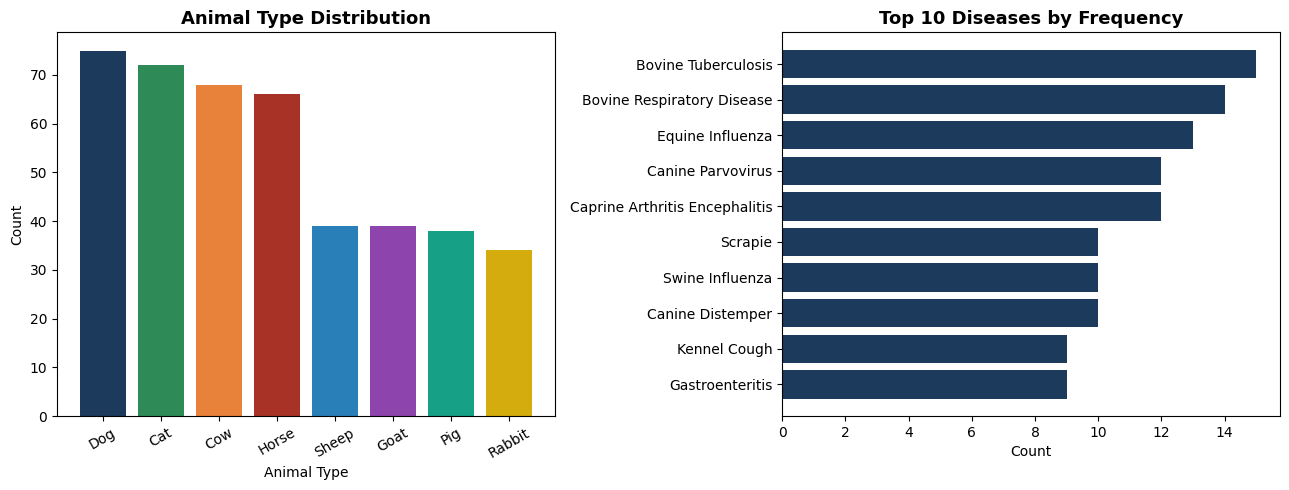


✅ Exploration complete


In [5]:
# ── Visualise animal type distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Animal type distribution
animal_counts = df['Animal_Type'].value_counts()
colors = ['#1B3A5C', '#2E8B57', '#E8813A', '#A93226', '#2980B9', '#8E44AD', '#16A085', '#D4AC0D']
axes[0].bar(animal_counts.index, animal_counts.values, color=colors[:len(animal_counts)])
axes[0].set_title("Animal Type Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Animal Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

# Top 10 diseases
top10 = df['Disease_Prediction'].value_counts().head(10)
axes[1].barh(top10.index[::-1], top10.values[::-1], color='#1B3A5C')
axes[1].set_title("Top 10 Diseases by Frequency", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()
print(f"\n✅ Exploration complete")

## 4. Parse & Clean Mixed-Format Columns

Two columns need cleaning before use:
- `Body_Temperature` — stored as string `"39.5°C"`, must be converted to float
- `Duration` — stored as string `"3 days"` / `"1 week"`, must be converted to integer (days)

In [6]:
# ── Body_Temperature: strip "°C" and convert to float ────────────────────
df['Body_Temperature_C'] = (
    df['Body_Temperature']
    .str.replace('°C', '', regex=False)
    .str.strip()
    .astype(float)
)

print(f"Body_Temperature_C range : [{df['Body_Temperature_C'].min():.1f}, {df['Body_Temperature_C'].max():.1f}] °C")
print(f"Mean                     :  {df['Body_Temperature_C'].mean():.2f} °C")

Body_Temperature_C range : [38.4, 40.2] °C
Mean                     :  39.30 °C


In [7]:
# ── Duration: convert to integer days ────────────────────────────────────
def parse_duration(val):
    """Converts duration string like '3 days', '1 week', '2 weeks' to integer days."""
    val = str(val).strip().lower()
    if 'week' in val:
        num = float(val.replace('weeks', '').replace('week', '').strip())
        return int(num * 7)
    elif 'day' in val:
        num = float(val.replace('days', '').replace('day', '').strip())
        return int(num)
    else:
        return int(val)

df['Duration_Days'] = df['Duration'].apply(parse_duration)

print(f"Duration_Days range : [{df['Duration_Days'].min()}, {df['Duration_Days'].max()}] days")
print(f"Unique values       : {sorted(df['Duration_Days'].unique())}")

Duration_Days range : [2, 14] days
Unique values       : [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(14)]


## 5. Encode Binary Symptom Flags

Columns like `Appetite_Loss`, `Vomiting`, `Diarrhea`, etc. are stored as  
`"Yes"` / `"No"` strings. We convert them to integers (1/0) for model compatibility.

In [8]:
BINARY_COLS = [
    'Appetite_Loss', 'Vomiting', 'Diarrhea', 'Coughing',
    'Labored_Breathing', 'Lameness', 'Skin_Lesions',
    'Nasal_Discharge', 'Eye_Discharge'
]

for col in BINARY_COLS:
    df[col + '_bin'] = (df[col].str.strip().str.lower() == 'yes').astype(int)

print("Binary symptom columns created:")
for col in BINARY_COLS:
    pos = df[col + '_bin'].sum()
    print(f"  {col}_bin : {pos} positive ({pos/len(df)*100:.1f}%)")

Binary symptom columns created:
  Appetite_Loss_bin : 381 positive (88.4%)
  Vomiting_bin : 247 positive (57.3%)
  Diarrhea_bin : 212 positive (49.2%)
  Coughing_bin : 288 positive (66.8%)
  Labored_Breathing_bin : 236 positive (54.8%)
  Lameness_bin : 246 positive (57.1%)
  Skin_Lesions_bin : 239 positive (55.5%)
  Nasal_Discharge_bin : 207 positive (48.0%)
  Eye_Discharge_bin : 225 positive (52.2%)


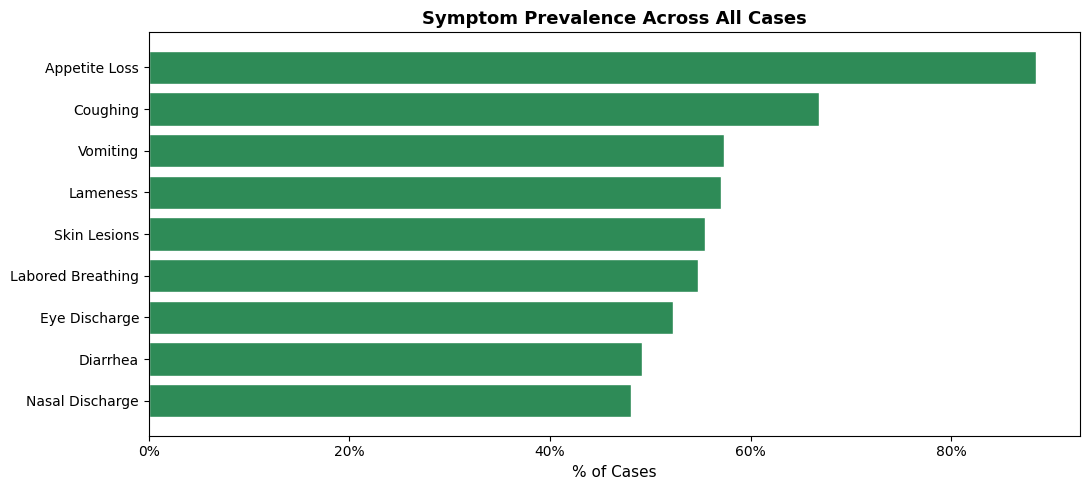

In [9]:
# ── Visualise symptom prevalence ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

bin_cols = [c + '_bin' for c in BINARY_COLS]
prevalence = df[bin_cols].mean().sort_values(ascending=True)
labels = [c.replace('_bin', '').replace('_', ' ') for c in prevalence.index]

ax.barh(labels, prevalence.values * 100, color='#2E8B57', edgecolor='white')
ax.set_xlabel("% of Cases", fontsize=11)
ax.set_title("Symptom Prevalence Across All Cases", fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.PercentFormatter())
plt.tight_layout()
plt.show()

## 6. Feature Engineering

We derive additional features to enrich the model's input space:

- **`symptom_count`** — total number of clinical symptoms reported (0–9)
- **`is_fever`** — flag for body temperature above 39.5 °C
- **`temp_deviation`** — how far body temperature deviates from the normal range midpoint (38.5 °C)
- **`high_heart_rate`** — flag for heart rate above 120 bpm

In [10]:
# ── Symptom count ─────────────────────────────────────────────────────────
bin_cols = [c + '_bin' for c in BINARY_COLS]
df['symptom_count'] = df[bin_cols].sum(axis=1)

print(f"symptom_count range : [{df['symptom_count'].min()}, {df['symptom_count'].max()}]")
print(f"Mean symptom count  : {df['symptom_count'].mean():.2f}")

# ── Fever flag ────────────────────────────────────────────────────────────
FEVER_THRESHOLD = 39.5
df['is_fever'] = (df['Body_Temperature_C'] > FEVER_THRESHOLD).astype(int)
print(f"\nis_fever (>{FEVER_THRESHOLD}°C): {df['is_fever'].sum()} cases ({df['is_fever'].mean()*100:.1f}%)")

# ── Temperature deviation from midpoint of normal range ──────────────────
NORMAL_TEMP_MID = 38.5
df['temp_deviation'] = (df['Body_Temperature_C'] - NORMAL_TEMP_MID).round(2)
print(f"temp_deviation range: [{df['temp_deviation'].min():.2f}, {df['temp_deviation'].max():.2f}]")

# ── High heart rate flag ──────────────────────────────────────────────────
df['high_heart_rate'] = (df['Heart_Rate'] > 120).astype(int)
print(f"high_heart_rate     : {df['high_heart_rate'].sum()} cases ({df['high_heart_rate'].mean()*100:.1f}%)")

symptom_count range : [1, 9]
Mean symptom count  : 5.29

is_fever (>39.5°C): 95 cases (22.0%)
temp_deviation range: [-0.10, 1.70]
high_heart_rate     : 143 cases (33.2%)


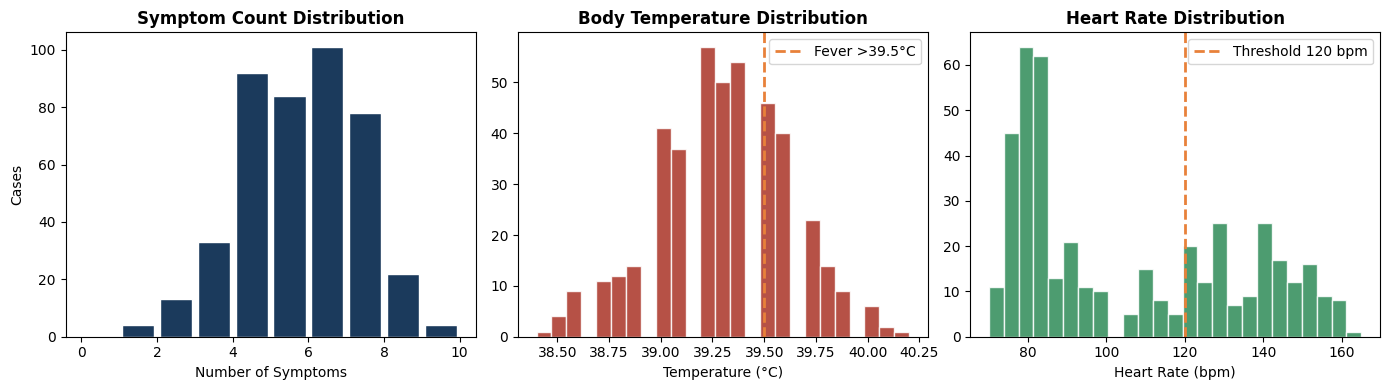

In [11]:
# ── Visualise engineered features ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Symptom count distribution
axes[0].hist(df['symptom_count'], bins=range(0, 11), color='#1B3A5C', edgecolor='white', rwidth=0.85)
axes[0].set_title("Symptom Count Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Number of Symptoms")
axes[0].set_ylabel("Cases")

# Body temperature distribution
axes[1].hist(df['Body_Temperature_C'], bins=25, color='#A93226', edgecolor='white', alpha=0.85)
axes[1].axvline(FEVER_THRESHOLD, color='#E8813A', linestyle='--', linewidth=2, label=f'Fever >{FEVER_THRESHOLD}°C')
axes[1].set_title("Body Temperature Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Temperature (°C)")
axes[1].legend()

# Heart rate distribution
axes[2].hist(df['Heart_Rate'], bins=25, color='#2E8B57', edgecolor='white', alpha=0.85)
axes[2].axvline(120, color='#E8813A', linestyle='--', linewidth=2, label='Threshold 120 bpm')
axes[2].set_title("Heart Rate Distribution", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Heart Rate (bpm)")
axes[2].legend()

plt.tight_layout()
plt.show()

## 7. Encode Categorical Variables

We encode categorical columns for model compatibility:
- `Gender` → binary (0/1)
- `Animal_Type` → one-hot encoding
- `Breed` → label encoding (too many unique values for one-hot)

The symptom text columns (`Symptom_1` to `Symptom_4`) are dropped here since  
the binary flags already capture their information.

In [12]:
# ── Gender → binary ──────────────────────────────────────────────────────
df['Gender_bin'] = (df['Gender'].str.strip().str.lower() == 'male').astype(int)
print(f"Gender_bin : Male=1 ({df['Gender_bin'].sum()}), Female=0 ({(df['Gender_bin']==0).sum()})")

# ── Animal_Type → one-hot ─────────────────────────────────────────────────
animal_dummies = pd.get_dummies(df['Animal_Type'], prefix='animal').astype(int)
df = pd.concat([df, animal_dummies], axis=1)
print(f"\nAnimal type dummies: {animal_dummies.columns.tolist()}")

# ── Breed → label encoding ────────────────────────────────────────────────
breed_map = {breed: i for i, breed in enumerate(df['Breed'].unique())}
df['Breed_encoded'] = df['Breed'].map(breed_map)
print(f"\nBreed_encoded : {df['Breed'].nunique()} unique breeds → 0 to {df['Breed_encoded'].max()}")

Gender_bin : Male=1 (225), Female=0 (206)

Animal type dummies: ['animal_Cat', 'animal_Cow', 'animal_Dog', 'animal_Goat', 'animal_Horse', 'animal_Pig', 'animal_Rabbit', 'animal_Sheep']

Breed_encoded : 120 unique breeds → 0 to 119


## 8. Encode Target Label (`Disease_Prediction`)

We assign a unique integer ID to each disease class, creating:
- `Disease_ID` — the integer target for classification models
- `disease_label_map.json` — the reverse mapping for human-readable predictions

In [13]:
diseases = sorted(df['Disease_Prediction'].unique())
disease_to_id = {disease: i for i, disease in enumerate(diseases)}
id_to_disease = {i: disease for disease, i in disease_to_id.items()}

df['Disease_ID'] = df['Disease_Prediction'].map(disease_to_id)

print(f"Total unique diseases : {len(diseases)}")
print(f"Disease_ID range      : [{df['Disease_ID'].min()}, {df['Disease_ID'].max()}]")
print(f"\nSample mappings:")
for disease, did in list(disease_to_id.items())[:5]:
    print(f"  {did:3d}  →  {disease}")
print("  ...")

Total unique diseases : 139
Disease_ID range      : [0, 138]

Sample mappings:
    0  →  Actinobacillus Pleuropneumonia
    1  →  Actinobacillus Suis
    2  →  African Swine Fever
    3  →  Allergic Rhinitis
    4  →  Arthritis
  ...


## 9. Normalize Numerical Features

Numerical features have very different scales (e.g., Weight: 1–700, Age: 0–15).  
We apply **min-max normalization** to bring all numerical features into the [0, 1] range,  
which improves convergence for gradient-based models.

In [14]:
NUMERICAL_COLS = ['Age', 'Weight', 'Duration_Days', 'Body_Temperature_C', 'Heart_Rate', 'temp_deviation']

scaler_params = {}

for col in NUMERICAL_COLS:
    col_min = df[col].min()
    col_max = df[col].max()
    df[col + '_norm'] = ((df[col] - col_min) / (col_max - col_min)).round(4)
    scaler_params[col] = {'min': col_min, 'max': col_max}
    print(f"{col}_norm : [{df[col+'_norm'].min():.3f}, {df[col+'_norm'].max():.3f}]")

print("\n✅ Normalization complete")

Age_norm : [0.000, 1.000]
Weight_norm : [0.000, 1.000]
Duration_Days_norm : [0.000, 1.000]
Body_Temperature_C_norm : [0.000, 1.000]
Heart_Rate_norm : [0.000, 1.000]
temp_deviation_norm : [0.000, 1.000]

✅ Normalization complete


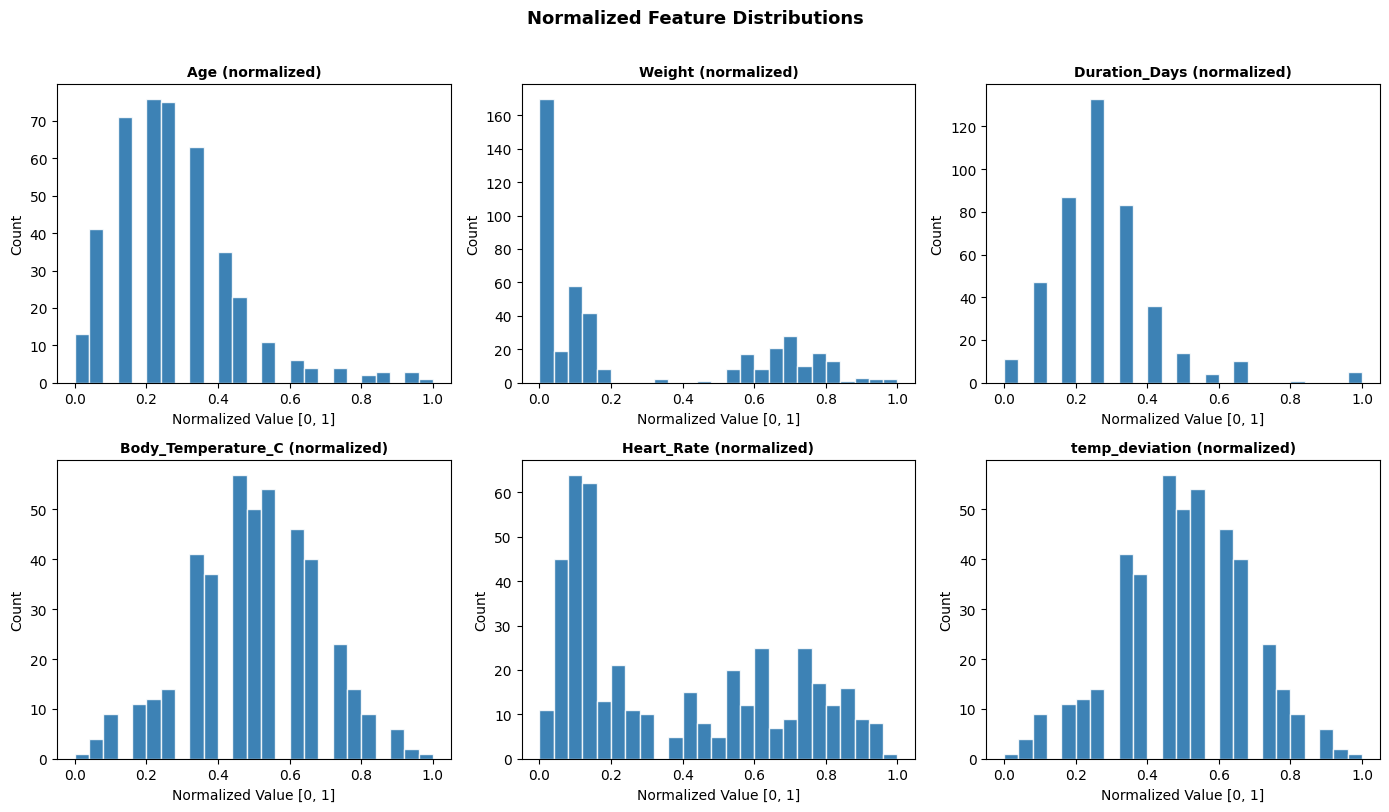

In [15]:
# ── Visualise before/after normalization ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    ax = axes[i]
    ax.hist(df[col + '_norm'], bins=25, color='#1B6CA8', edgecolor='white', alpha=0.85)
    ax.set_title(f"{col} (normalized)", fontsize=10, fontweight='bold')
    ax.set_xlabel("Normalized Value [0, 1]")
    ax.set_ylabel("Count")

plt.suptitle("Normalized Feature Distributions", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Final Column Structure, Quality Check & Save

We select the final columns in a logical order, run a quality check,  
then save the ML-ready dataset and the label mapping.

In [16]:
# ── Final column selection ────────────────────────────────────────────────
animal_dummy_cols = [c for c in df.columns if c.startswith('animal_')]

final_cols = (
    # Identifiers
    ['Animal_Type', 'Breed']
    # Numerical features (normalized)
    + ['Age_norm', 'Weight_norm', 'Duration_Days_norm',
       'Body_Temperature_C_norm', 'Heart_Rate_norm', 'temp_deviation_norm']
    # Binary clinical flags
    + [c + '_bin' for c in BINARY_COLS]
    # Engineered features
    + ['symptom_count', 'is_fever', 'high_heart_rate']
    # Encoded categoricals
    + ['Gender_bin', 'Breed_encoded']
    + animal_dummy_cols
    # Target
    + ['Disease_Prediction', 'Disease_ID']
)

df_final = df[final_cols].reset_index(drop=True)
print(f"Final dataset shape : {df_final.shape}")
print(f"Final columns       : {df_final.columns.tolist()}")
df_final.head(3)

Final dataset shape : (431, 32)
Final columns       : ['Animal_Type', 'Breed', 'Age_norm', 'Weight_norm', 'Duration_Days_norm', 'Body_Temperature_C_norm', 'Heart_Rate_norm', 'temp_deviation_norm', 'Appetite_Loss_bin', 'Vomiting_bin', 'Diarrhea_bin', 'Coughing_bin', 'Labored_Breathing_bin', 'Lameness_bin', 'Skin_Lesions_bin', 'Nasal_Discharge_bin', 'Eye_Discharge_bin', 'symptom_count', 'is_fever', 'high_heart_rate', 'Gender_bin', 'Breed_encoded', 'animal_Cat', 'animal_Cow', 'animal_Dog', 'animal_Goat', 'animal_Horse', 'animal_Pig', 'animal_Rabbit', 'animal_Sheep', 'Disease_Prediction', 'Disease_ID']


,Animal_Type,Breed,Age_norm,Weight_norm,Duration_Days_norm,Body_Temperature_C_norm,Heart_Rate_norm,temp_deviation_norm,Appetite_Loss_bin,Vomiting_bin,...,animal_Cat,animal_Cow,animal_Dog,animal_Goat,animal_Horse,animal_Pig,animal_Rabbit,animal_Sheep,Disease_Prediction,Disease_ID
0,Dog,Labrador,0.2000,0.0283,0.0833,0.6111,0.5263,0.6111,1,1,...,0,0,1,0,0,0,0,0,Parvovirus,109
1,Cat,Siamese,0.0667,0.0041,0.4167,0.2778,0.8421,0.2778,0,0,...,1,0,0,0,0,0,0,0,Upper Respiratory Infection,136
2,Cow,Holstein,0.1333,0.7055,0.2500,0.9444,0.2105,0.9444,1,0,...,0,1,0,0,0,0,0,0,Foot and Mouth Disease,86


In [17]:
# ── Quality check ─────────────────────────────────────────────────────────
print("=" * 50)
print("  FINAL DATASET — QUALITY REPORT")
print("=" * 50)

print(f"\n📊 Shape          : {df_final.shape}")

nulls = df_final.isnull().sum()
print(f"🔍 Missing values  : {nulls.sum()} (should be 0)")
if nulls.sum() > 0:
    print(nulls[nulls > 0])

print(f"\n🎯 Target classes  : {df_final['Disease_ID'].nunique()} unique diseases")
print(f"   Disease_ID range : [{df_final['Disease_ID'].min()}, {df_final['Disease_ID'].max()}]")

num_feature_cols = [c for c in df_final.columns
                    if c.endswith('_norm') or c.endswith('_bin')
                    or c in ['symptom_count', 'is_fever', 'high_heart_rate', 'Gender_bin', 'Breed_encoded']
                    or c.startswith('animal_')]
print(f"\n🔢 Feature columns : {len(num_feature_cols)}")

print("\n✅ Quality check passed — ready to train!")

  FINAL DATASET — QUALITY REPORT

📊 Shape          : (431, 32)
🔍 Missing values  : 0 (should be 0)

🎯 Target classes  : 139 unique diseases
   Disease_ID range : [0, 138]

🔢 Feature columns : 28

✅ Quality check passed — ready to train!


In [18]:
# ── Save dataset ──────────────────────────────────────────────────────────
df_final.to_csv('animal_disease_ml_ready.csv', index=False)
print("✅ Saved: animal_disease_ml_ready.csv")

# ── Save disease label map ────────────────────────────────────────────────
label_map = {
    "disease_to_id": disease_to_id,
    "id_to_disease": id_to_disease,
    "total_classes": len(disease_to_id),
    "scaler_params": scaler_params
}

with open('disease_label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)
print("✅ Saved: disease_label_map.json")

✅ Saved: animal_disease_ml_ready.csv


TypeError: Object of type int64 is not JSON serializable

---

## Summary

| Step | What was done | Key output |
|------|--------------|------------|
| 1 | Loaded raw clinical animal dataset | `df` — 431 rows × 22 columns |
| 2 | Explored distributions and quality | No missing values confirmed |
| 3 | Parsed `Body_Temperature` & `Duration` | `Body_Temperature_C`, `Duration_Days` |
| 4 | Encoded binary symptom flags | 9 `*_bin` columns |
| 5 | Engineered new features | `symptom_count`, `is_fever`, `temp_deviation`, `high_heart_rate` |
| 6 | Encoded categorical variables | `Gender_bin`, `Breed_encoded`, `animal_*` dummies |
| 7 | Encoded target labels | `Disease_ID` (0–138), `disease_label_map.json` |
| 8 | Normalized numerical features | 6 `*_norm` columns |
| 9 | Quality check & save | `animal_disease_ml_ready.csv` ✅ |

**Next step:** Use `animal_disease_ml_ready.csv` to train a classification model  
(e.g., Random Forest, XGBoost, or a neural network) with `Disease_ID` as the target.